In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px

In [18]:
# ==============================
# CONFIGURACIÓN
# ==============================

assets = ["SAN.MC", "BBVA.MC", "^IBEX", "^GSPC"]
start_date = "2019-01-01"
end_date = "2026-01-01"
trading_days = 252 # Número típico de días de trading en un año (excluyendo fines de semana y festivos)
risk_free_rate = 0.02  # 2% anual

In [19]:
# ==============================
# DESCARGA DE PRECIOS AJUSTADOS
# ==============================

data = yf.download(
    assets,
    start=start_date,
    end=end_date,
    auto_adjust=True # Descarga precios ajustados automáticamente (dividendos y splits incluidos)
)

# Extraer precios de cierre ajustados correctamente
if isinstance(data.columns, pd.MultiIndex):
    prices = data["Close"]
else:
    prices = data["Close"]

prices = prices.dropna() # Eliminamos días donde falten datos en algún activo

[*********************100%***********************]  4 of 4 completed


In [20]:

# ==============================
# RETORNOS DIARIOS SIMPLES
# ==============================

daily_returns = prices.pct_change().dropna()

In [21]:

# ==============================
# RETORNOS DIARIOS ACUMULADOS
# ==============================

cumulative_returns = (1 + daily_returns).cumprod() - 1
print("\n=== RETORNOS DIARIOS ACUMULADOS ===\n")
print(cumulative_returns.tail())  # muestra últimas filas

# Si quieres guardarlo:
# cumulative_returns.to_csv("retornos_acumulados.csv")


=== RETORNOS DIARIOS ACUMULADOS ===

Ticker       BBVA.MC    SAN.MC     ^GSPC     ^IBEX
Date                                              
2025-12-23  5.302349  2.311517  1.752871  1.009684
2025-12-24  5.295973  2.307213  1.761740  1.008526
2025-12-29  5.308725  2.299598  1.751258  1.011205
2025-12-30  5.401172  2.352572  1.747473  1.029813
2025-12-31  5.391608  2.334031  1.727258  1.024304


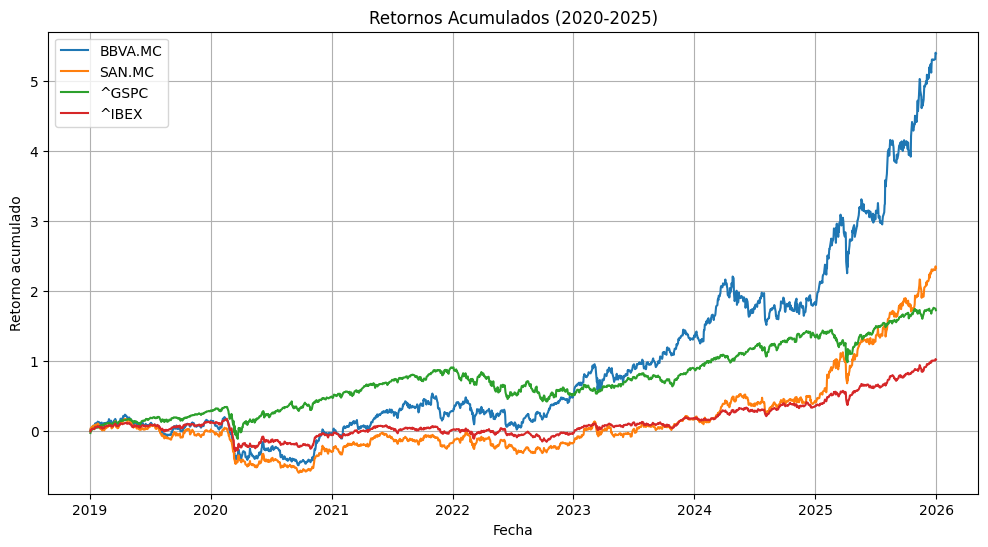

In [22]:

# ==============================
# GRÁFICO DE RETORNOS ACUMULADOS
# ==============================

plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns)
plt.title("Retornos Acumulados (2020-2025)")
plt.xlabel("Fecha")
plt.ylabel("Retorno acumulado")
plt.legend(cumulative_returns.columns)
plt.grid(True)
plt.savefig("retornos_acumulados.png", dpi=300, bbox_inches="tight")
plt.show()

### Comentarios:

- El BBVA sobrepasó a los demás activos en términos absolutos pero presenta más dependencia a los shocks.
- El IBEX queda por detrás del S&P en retorno acumulado.
- EL S&P muestra un crecimiento más estable.

In [23]:
# ==============================
# VOLATILIDAD ANUALIZADA
# ==============================

vol_annual = daily_returns.std() * np.sqrt(trading_days)

# Convertir a porcentaje
vol_annual = vol_annual * 100

print("\n=== VOLATILIDAD ANUALIZADA (2020-2025) ===\n")
print(vol_annual.round(2).astype(str) + " %")


=== VOLATILIDAD ANUALIZADA (2020-2025) ===

Ticker
BBVA.MC    35.98 %
SAN.MC     35.35 %
^GSPC      19.97 %
^IBEX      19.35 %
dtype: str


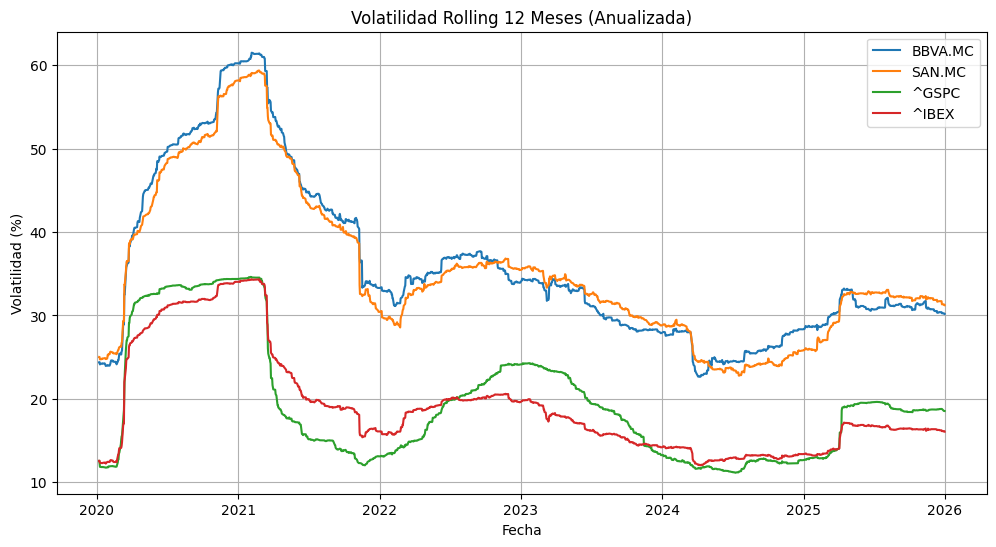

In [24]:
# ==================================
# GRÁFICO DE VOLATILIDAD ROLLING 12M
# ==================================

rolling_vol_12m = (
    daily_returns
    .rolling(window=252) # Ventana de 252 días para volatilidad móvil (aprox. 12 meses)
    .std()
    * np.sqrt(trading_days)
)

# Convertir a porcentaje
rolling_vol_12m = rolling_vol_12m * 100

plt.figure(figsize=(12,6))
plt.plot(rolling_vol_12m)
plt.title("Volatilidad Rolling 12 Meses (Anualizada)")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad (%)")
plt.legend(rolling_vol_12m.columns)
plt.grid(True)
plt.show()

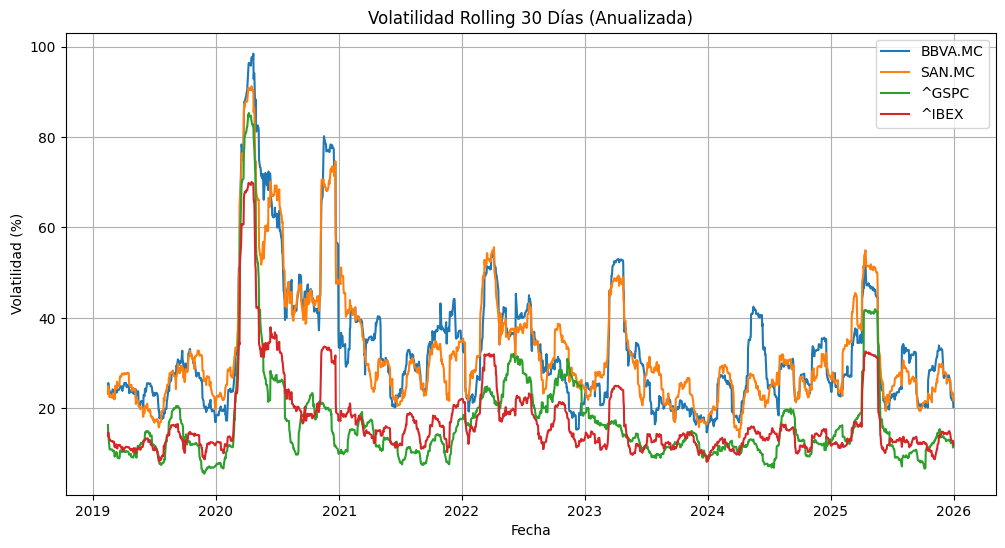

In [25]:
# ==================================
# GRÁFICO DE VOLATILIDAD ROLLING 30D
# ==================================

rolling_vol_30d = (
    daily_returns
    .rolling(window=30) # Ventana de 30 días para volatilidad móvil
    .std()
    * np.sqrt(trading_days) # Escalamos a anualizada usando el número de días de trading en un año
)

# Convertir a porcentaje
rolling_vol_30d = rolling_vol_30d * 100

plt.figure(figsize=(12,6))
plt.plot(rolling_vol_30d)
plt.title("Volatilidad Rolling 30 Días (Anualizada)")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad (%)")
plt.legend(rolling_vol_30d.columns)
plt.grid(True)
plt.show()

In [26]:
# ==================================================================
# GRÁFICO INTERACTIVO COMPARANDO VOLATILIDAD 12M CON VOLATILIDAD 30D
# ==================================================================

fig = go.Figure()

for ticker in rolling_vol_30d.columns:
    
    # Volatilidad 30D (línea sólida)
    fig.add_trace(go.Scatter(
        x=rolling_vol_30d.index,
        y=rolling_vol_30d[ticker],
        mode='lines',
        name=f"{ticker} - 30D",
    ))
    
    # Volatilidad 12M (línea discontinua)
    fig.add_trace(go.Scatter(
        x=rolling_vol_12m.index,
        y=rolling_vol_12m[ticker],
        mode='lines',
        name=f"{ticker} - 12M",
        line=dict(dash='dash')
    ))

fig.update_layout(
    title="Comparación Volatilidad Rolling 30D vs 12M (Anualizada)",
    xaxis_title="Fecha",
    yaxis_title="Volatilidad (%)",
    template="plotly_white",
    hovermode="x unified",
    height=700
)

fig.show()

# Guardar en HTML interactivo
pio.write_html(
    fig,
    file="comparacion_volatilidad_30D_vs_12M.html",
    auto_open=True,
    include_plotlyjs="cdn"
)

### Comentarios:

- Se puede ver como la volatilidad 30D reacciona en momentos de crisis o novedades bastante antes que la 12M.
- La 12M, por otro lado, es más suave y refleja cambios más estructurales.
- Cuando la línea 30D está por debajo de la de 12M se considera que hay una normalización tras una crisis.
- Cuando la línea 30D cruza por encima de la de 12M aumenta el riesgo
- Los bancos presentan una mayor volatilidad estructural que los índices.


In [27]:
# 
# ==============================
# SHARPE RATIO
# ==============================

rf_daily = risk_free_rate / trading_days # Convertimos tasa anual a diaria dividiendo por número de días de trading
excess_returns = daily_returns - rf_daily # Exceso de retorno diario

# Media diaria de exceso
mean_excess_daily = excess_returns.mean()

# Sharpe anualizado directo
sharpe_ratio = (
    mean_excess_daily / daily_returns.std()
) * np.sqrt(trading_days)

print("\n=== SHARPE RATIO 2019-2026 ===\n")
print(sharpe_ratio.round(3))


=== SHARPE RATIO 2019-2026 ===

Ticker
BBVA.MC    0.871
SAN.MC     0.613
^GSPC      0.727
^IBEX      0.522
dtype: float64


In [28]:
print(mean_excess_daily)
print(daily_returns.std())

Ticker
BBVA.MC    0.001243
SAN.MC     0.000860
^GSPC      0.000576
^IBEX      0.000400
dtype: float64
Ticker
BBVA.MC    0.022662
SAN.MC     0.022267
^GSPC      0.012578
^IBEX      0.012188
dtype: float64


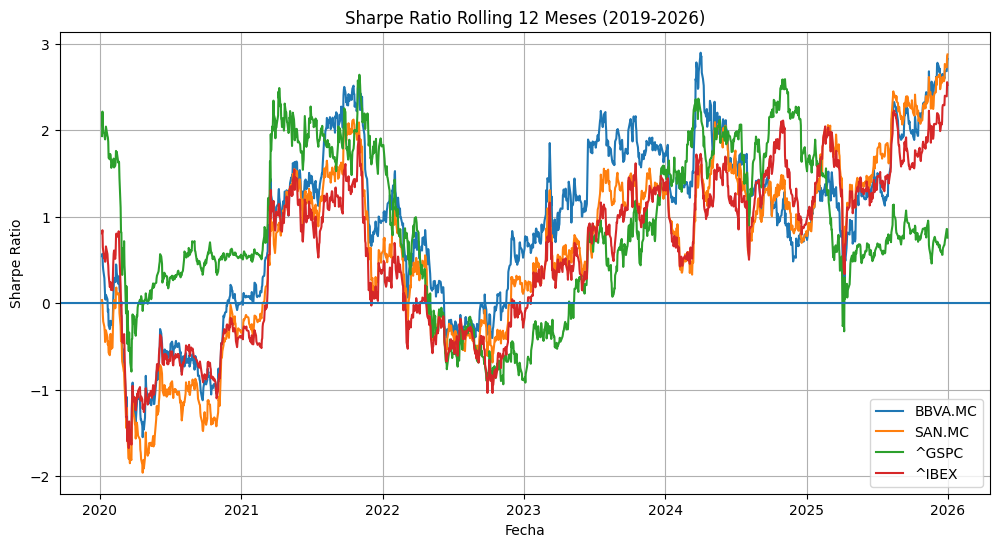

In [29]:
# ==============================
# GRÁFICO DE SHARPE ROLLING 12M
# ==============================

rolling_mean = excess_returns.rolling(252).mean() * trading_days
rolling_vol = daily_returns.rolling(252).std() * np.sqrt(trading_days)

rolling_sharpe = rolling_mean / rolling_vol

# ==============================
# GRÁFICO
# ==============================

plt.figure(figsize=(12,6))
plt.plot(rolling_sharpe)
plt.title("Sharpe Ratio Rolling 12 Meses (2019-2026)")
plt.xlabel("Fecha")
plt.ylabel("Sharpe Ratio")
plt.legend(rolling_sharpe.columns)
plt.axhline(0)
plt.grid(True)
plt.show()

In [30]:
# ==================================================================
# GRÁFICO INTERACTIVO COMPARANDO SHARPE ROLLING 12M CON SHARPE TOTAL
# ==================================================================

fig = go.Figure()

for ticker in assets:
    
    # Sharpe rolling
    fig.add_trace(go.Scatter(
        x=rolling_sharpe.index,
        y=rolling_sharpe[ticker],
        mode='lines',
        name=f"{ticker} Rolling 12M"
    ))
    
    # Línea horizontal Sharpe total
    fig.add_trace(go.Scatter(
        x=rolling_sharpe.index,
        y=[sharpe_ratio[ticker]] * len(rolling_sharpe),
        mode='lines',
        name=f"{ticker} Sharpe Total",
        line=dict(dash="dash")
    ))

fig.update_layout(
    title="Sharpe Ratio Rolling 12M vs Sharpe Total (2019-2026)",
    yaxis_title="Sharpe Ratio",
    xaxis_title="Fecha",
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

pio.write_html(
    fig,
    file="sharpe_rolling_2019_2026.html",
    auto_open=True,
    include_plotlyjs="cdn"
)

### Comentarios:

El ratio de Sharpe nos informa de la rentabilidad por cada unidad de riesgo que se asume. Cuanto más alto sea su valor, más apetecible es la inversión porque el riesgo se verá compensado con la volatilidad. Cuando su valor es negativo indica que el rendimiento es menor al de la rentabilidad sin riesgo (en este caso se ha cogido como referencia el rendimiento de un bono alemán a 10 años: 2% anual). Observando el gráfico se puede destacar lo siguiente:

- El Sharpe Total suaviza y no refleja los cambios que hubo a lo largo del tiempo.
- En general, el Sharpe Rolling de S&P 500 es el más estable estructuralmente: la explicación es que tiene mayor diversificación sectorial que los otros activos con los que estamos comparando.
- La banca española tiene mayor sensibilidad a los tipos, el riesgo país y/o el ciclo económico.

In [31]:
# =====================
# MATRIZ DE CORRELACIÓN
# =====================
correlation_matrix = daily_returns.corr()

print("=== MATRIZ DE CORRELACIÓN ===")
print(correlation_matrix.round(3))

=== MATRIZ DE CORRELACIÓN ===
Ticker   BBVA.MC  SAN.MC  ^GSPC  ^IBEX
Ticker                                
BBVA.MC    1.000   0.838  0.392  0.808
SAN.MC     0.838   1.000  0.399  0.837
^GSPC      0.392   0.399  1.000  0.511
^IBEX      0.808   0.837  0.511  1.000


In [32]:
# ==================================
# HEATMAP INTERACTIVO DE CORRELACIÓN
# ==================================

fig_corr = px.imshow(
    correlation_matrix,
    text_auto=True,
    aspect="auto",
    color_continuous_scale="RdBu",
    zmin=-1,
    zmax=1
)

fig_corr.update_layout(
    title="Matriz de Correlación (2019-2026)",
)

fig_corr.show()

# Guardar como HTML
fig_corr.write_html("correlacion_2019_2026.html", auto_open=True)

### Comentarios:

Una correlación mayor a 0.75 indica que los activos tienen una relación positiva fuerte, es decir, tienden a moverse en la misma dirección. Esto puede deberse a pertenecer al mismo sector, presentar una sensibilidad similar a tipos de interés y compartir parcialmente el riesgo país. En este caso:

- El IBEX 35 tiene una alta correlación con SAN y BBVA, lo cual es lógico ya que ambos bancos son componentes importantes del índice. 
- La correlación del IBEX 35 con el S&P 500 es más baja, lo que refleja la diferencia geográfica y sectorial entre los mercados español y estadounidense.
- La correlación entre los bancos españoles y S&P 500 es todavía más baja.

# Conclusiones

> 📌 Desde el punto de vista de la construcción de una cartera, contar con las dos acciones de los bancos a la vez no aportaría diversificación. Invertir en el IBEX y a mayores en los bancos, tampoco. Sin embargo, sí es interesante incluir alguna de las anteriores y S&P para tener en cuenta las diferencias sectoriales y geográficas, además de un crecimiento más estable. La banca española podría considerarse una posición táctica según el momento, ya que el riesgo en banca es más dependiente del ciclo y el entorno. Sería recomendable añadir otras clases de activo.